In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from scipy import sparse
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

BASE_DIR = Path("/data5/zhangye/scMRDR/scMRDR_zy/PBMC/output_pbmc_multiome/results_scMRDR_loop")
ratio_label = "single_000"   # 改这里，比如 single_020 / single_040 ...
outdir = BASE_DIR / ratio_label

FIGDIR = outdir / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

print("Using:", outdir)

Using: /data5/zhangye/scMRDR/scMRDR_zy/PBMC/output_pbmc_multiome/results_scMRDR_loop/single_000


In [2]:
pred_rna_val = sc.read_h5ad(outdir / "pred_rna_val.h5ad")
true_rna_val = sc.read_h5ad(outdir / "true_rna_val.h5ad")

t1_metrics = pd.read_csv(outdir / "T1_metrics.csv")
t2_metrics = pd.read_csv(outdir / "T2_metrics.csv")
t1_per_cell = pd.read_csv(outdir / "T1_per_cell_metrics.csv")
t2_cellwise = pd.read_csv(outdir / "T2_cellwise_pearson.csv")
t2_genewise = pd.read_csv(outdir / "T2_genewise_pearson.csv")

print(pred_rna_val.shape, true_rna_val.shape)
display(t1_metrics)
display(t2_metrics)

(2382, 19115) (2382, 19115)


,metric,value
0,paired_embedding_distance_mean,67.726957
1,paired_embedding_distance_median,59.843964
2,FOSCTTM,0.449217
3,Top1_ACC,0.004618
4,Top5_ACC,0.010915
5,Top10_ACC,0.021411


,metric,value
0,pearson_cell_mean,0.515670
1,pearson_gene_mean,0.065791
2,rmse,0.653259


In [3]:
def to_dense(x):
    if sparse.issparse(x):
        return x.toarray()
    return np.asarray(x)

def scale_rows(mat):
    mat = np.asarray(mat, dtype=float)
    row_mean = np.nanmean(mat, axis=1, keepdims=True)
    row_std = np.nanstd(mat, axis=1, keepdims=True)
    row_std[row_std == 0] = 1.0
    return (mat - row_mean) / row_std

def get_common_names(*arrays):
    if len(arrays) == 0:
        return []
    common = set(arrays[0])
    for arr in arrays[1:]:
        common &= set(arr)
    return sorted(common)

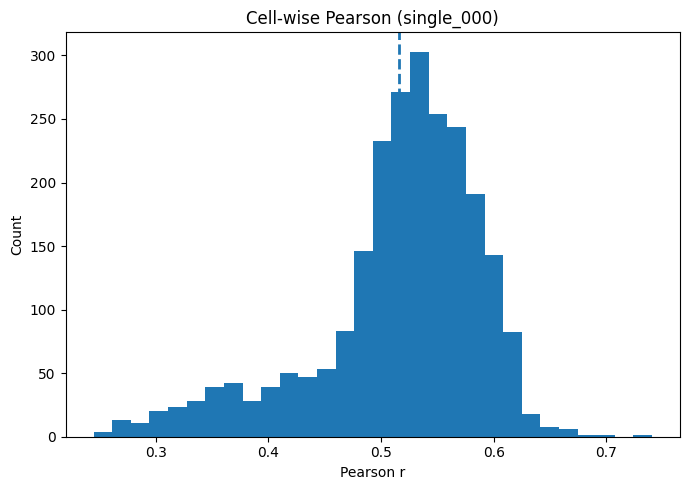

In [4]:
cell_cor = t2_cellwise["cellwise_pearson"].to_numpy()

plt.figure(figsize=(7, 5))
plt.hist(cell_cor[~np.isnan(cell_cor)], bins=30)
plt.axvline(np.nanmean(cell_cor), linestyle="--", linewidth=2)
plt.xlabel("Pearson r")
plt.ylabel("Count")
plt.title(f"Cell-wise Pearson ({ratio_label})")
plt.tight_layout()
plt.savefig(FIGDIR / "Fig2_cellwise_pearson_hist.png", dpi=200)
plt.show()

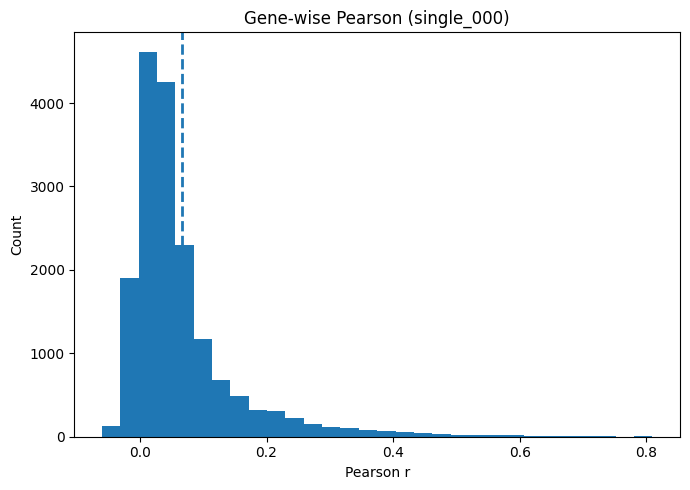

In [5]:
gene_cor = t2_genewise["genewise_pearson"].to_numpy()

plt.figure(figsize=(7, 5))
plt.hist(gene_cor[~np.isnan(gene_cor)], bins=30)
plt.axvline(np.nanmean(gene_cor), linestyle="--", linewidth=2)
plt.xlabel("Pearson r")
plt.ylabel("Count")
plt.title(f"Gene-wise Pearson ({ratio_label})")
plt.tight_layout()
plt.savefig(FIGDIR / "Fig3_genewise_pearson_hist.png", dpi=200)
plt.show()

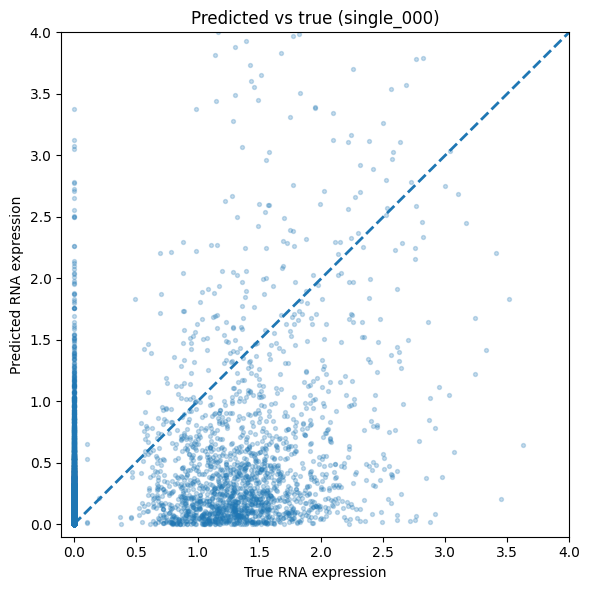

In [6]:
common_cells = get_common_names(pred_rna_val.obs_names.tolist(), true_rna_val.obs_names.tolist())
common_features = get_common_names(pred_rna_val.var_names.tolist(), true_rna_val.var_names.tolist())

pred_use = pred_rna_val[common_cells, common_features].copy()
true_use = true_rna_val[common_cells, common_features].copy()

pred_vec = to_dense(pred_use.X).ravel()
true_vec = to_dense(true_use.X).ravel()

rng = np.random.default_rng(1234)
n_sample = min(20000, len(true_vec))
idx = rng.choice(len(true_vec), size=n_sample, replace=False)

plt.figure(figsize=(6, 6))
plt.scatter(true_vec[idx], pred_vec[idx], s=8, alpha=0.25)
mn = min(true_vec[idx].min(), pred_vec[idx].min())
mx = max(true_vec[idx].max(), pred_vec[idx].max())
plt.plot([mn, mx], [mn, mx], linestyle="--", linewidth=2)
plt.xlim((-0.1,4))
plt.ylim((-0.1,4))
plt.xlabel("True RNA expression")
plt.ylabel("Predicted RNA expression")
plt.title(f"Predicted vs true ({ratio_label})")
plt.tight_layout()
plt.savefig(FIGDIR / "Fig4_global_pred_vs_true_scatter.png", dpi=200)
plt.show()

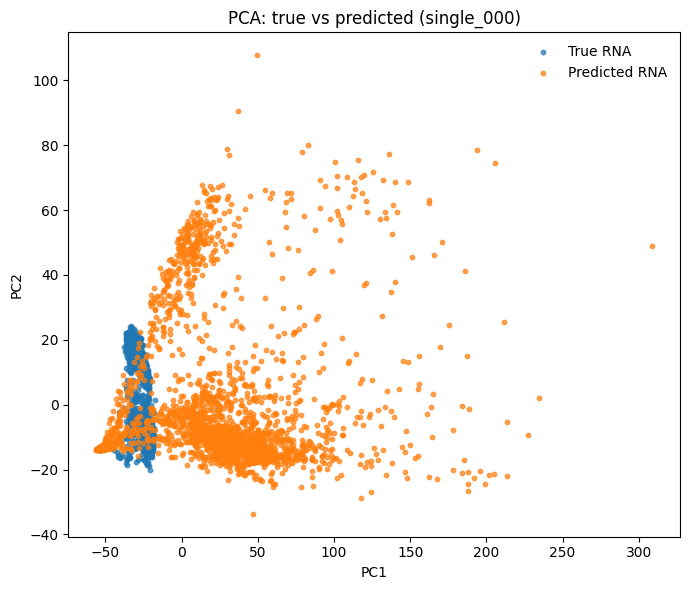

In [7]:
true_mat = to_dense(true_use.X)
pred_mat = to_dense(pred_use.X)

mix = np.vstack([true_mat, pred_mat])   # cells x features
n_components = min(30, mix.shape[0] - 1, mix.shape[1])

pca = PCA(n_components=n_components, random_state=1234)
emb = pca.fit_transform(mix)

nq = true_mat.shape[0]
plot_df = pd.DataFrame({
    "PC1": emb[:, 0],
    "PC2": emb[:, 1],
    "type": ["True_RNA"] * nq + ["Pred_from_ATAC"] * nq
})

plt.figure(figsize=(7, 6))
mask_true = plot_df["type"] == "True_RNA"
mask_pred = plot_df["type"] == "Pred_from_ATAC"

plt.scatter(plot_df.loc[mask_true, "PC1"], plot_df.loc[mask_true, "PC2"], s=10, alpha=0.7, label="True RNA")
plt.scatter(plot_df.loc[mask_pred, "PC1"], plot_df.loc[mask_pred, "PC2"], s=10, alpha=0.7, label="Predicted RNA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"PCA: true vs predicted ({ratio_label})")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIGDIR / "Fig5_pca_true_vs_pred.png", dpi=200)
plt.show()

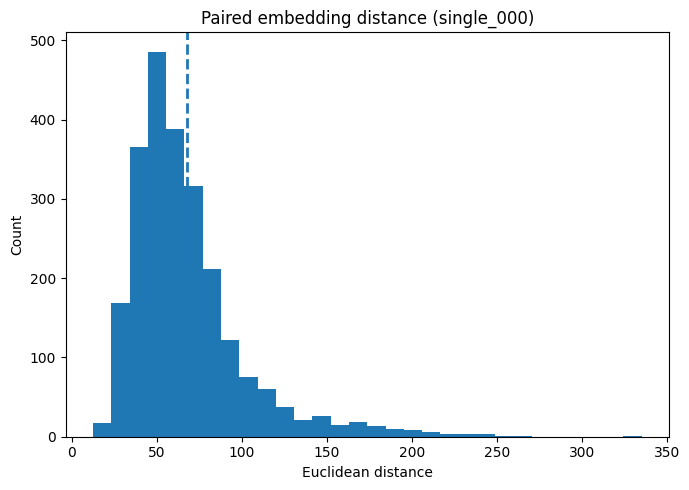

In [8]:
paired_dist = t1_per_cell["paired_dist"].to_numpy()

plt.figure(figsize=(7, 5))
plt.hist(paired_dist[~np.isnan(paired_dist)], bins=30)
plt.axvline(np.nanmean(paired_dist), linestyle="--", linewidth=2)
plt.xlabel("Euclidean distance")
plt.ylabel("Count")
plt.title(f"Paired embedding distance ({ratio_label})")
plt.tight_layout()
plt.savefig(FIGDIR / "Fig6_paired_distance_hist.png", dpi=200)
plt.show()

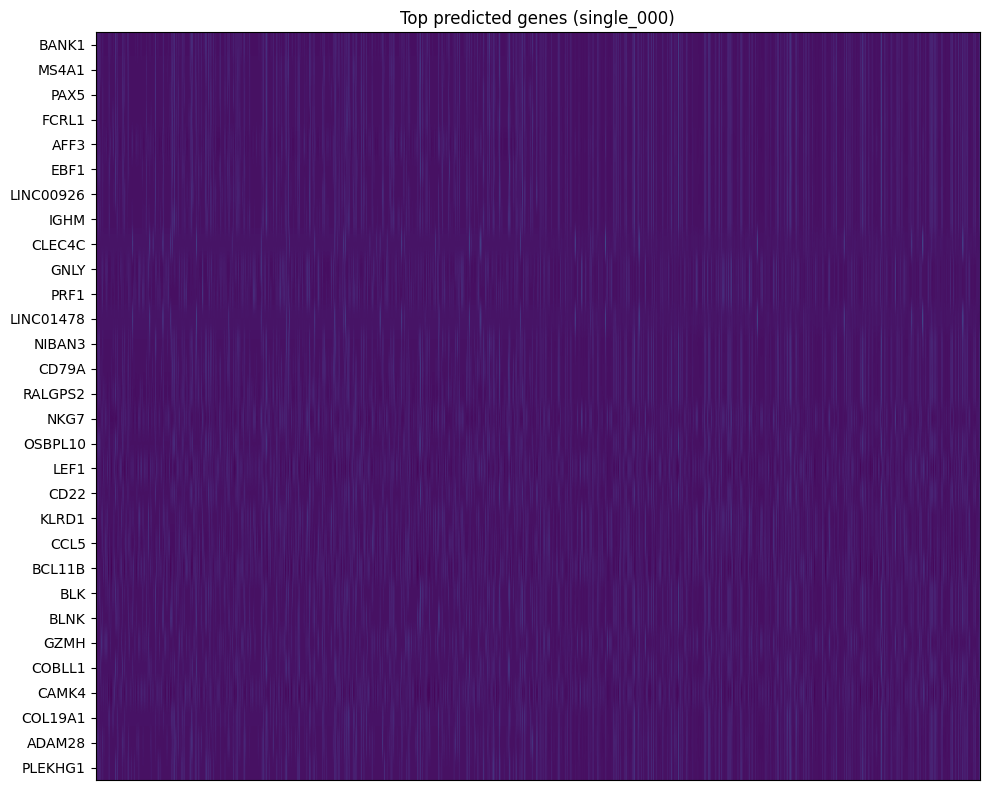

In [9]:
top_n = 30
gene_cor_df = t2_genewise.dropna().sort_values("genewise_pearson", ascending=False)
top_genes = gene_cor_df["gene"].tolist()[:top_n]

if len(top_genes) > 1:
    true_top = to_dense(true_use[:, top_genes].X).T   # gene x cell
    pred_top = to_dense(pred_use[:, top_genes].X).T   # gene x cell

    true_top_z = scale_rows(true_top)
    pred_top_z = scale_rows(pred_top)
    heatmap_mat = np.concatenate([true_top_z, pred_top_z], axis=1)

    plt.figure(figsize=(10, 8))
    plt.imshow(heatmap_mat, aspect="auto")
    plt.yticks(np.arange(len(top_genes)), top_genes)
    plt.xticks([])
    plt.title(f"Top predicted genes ({ratio_label})")
    plt.tight_layout()
    plt.savefig(FIGDIR / "Fig7_top_gene_heatmap.png", dpi=200)
    plt.show()

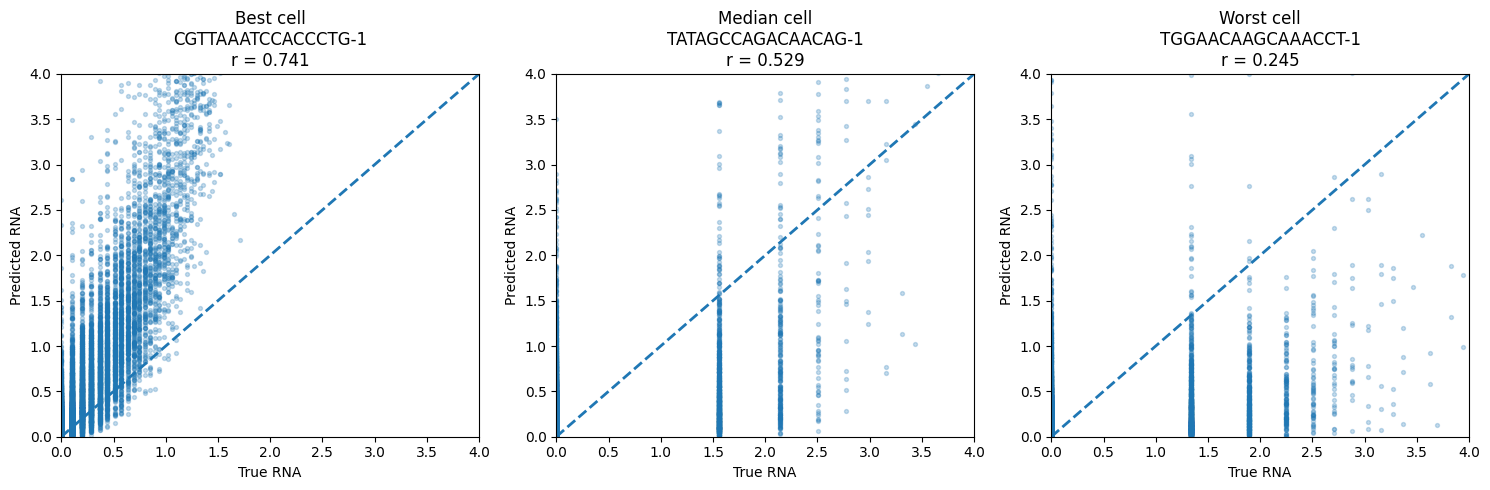

In [10]:
cell_df = t2_cellwise.dropna().sort_values("cellwise_pearson", ascending=False)
ordered_cells = cell_df["cell"].tolist()

if len(ordered_cells) >= 3:
    best_cell = ordered_cells[0]
    median_cell = ordered_cells[len(ordered_cells) // 2]
    worst_cell = ordered_cells[-1]

    example_cells = [best_cell, median_cell, worst_cell]
    labels = ["Best", "Median", "Worst"]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, cell, lab in zip(axes, example_cells, labels):
        x = to_dense(true_use[cell, :].X).ravel()
        y = to_dense(pred_use[cell, :].X).ravel()

        ax.scatter(x, y, s=8, alpha=0.25)
        mn = min(x.min(), y.min())
        mx = max(x.max(), y.max())
        ax.plot([mn, mx], [mn, mx], linestyle="--", linewidth=2)
        r = cell_df.loc[cell_df["cell"] == cell, "cellwise_pearson"].iloc[0]
        ax.set_xlim((0,4))
        ax.set_ylim((0,4))
        ax.set_title(f"{lab} cell\n{cell}\nr = {r:.3f}")
        ax.set_xlabel("True RNA")
        ax.set_ylabel("Predicted RNA")

    plt.tight_layout()
    plt.savefig(FIGDIR / "Fig8_example_cells_scatter.png", dpi=200)
    plt.show()

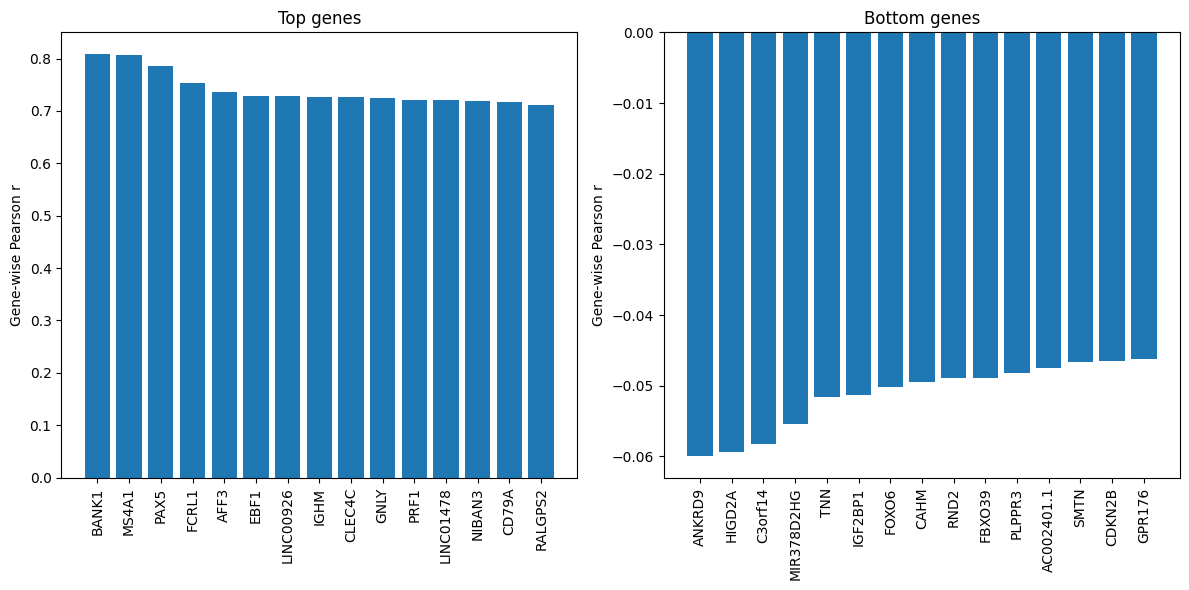

In [11]:
gene_df = t2_genewise.dropna().sort_values("genewise_pearson", ascending=False)

if len(gene_df) >= 15:
    top_k = 15
    top_genes_bar = gene_df.head(top_k)
    bottom_genes_bar = gene_df.tail(top_k).sort_values("genewise_pearson", ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].bar(np.arange(top_k), top_genes_bar["genewise_pearson"].to_numpy())
    axes[0].set_xticks(np.arange(top_k))
    axes[0].set_xticklabels(top_genes_bar["gene"].tolist(), rotation=90)
    axes[0].set_title("Top genes")
    axes[0].set_ylabel("Gene-wise Pearson r")

    axes[1].bar(np.arange(top_k), bottom_genes_bar["genewise_pearson"].to_numpy())
    axes[1].set_xticks(np.arange(top_k))
    axes[1].set_xticklabels(bottom_genes_bar["gene"].tolist(), rotation=90)
    axes[1].set_title("Bottom genes")
    axes[1].set_ylabel("Gene-wise Pearson r")

    plt.tight_layout()
    plt.savefig(FIGDIR / "Fig9_top_bottom_genes_barplot.png", dpi=200)
    plt.show()

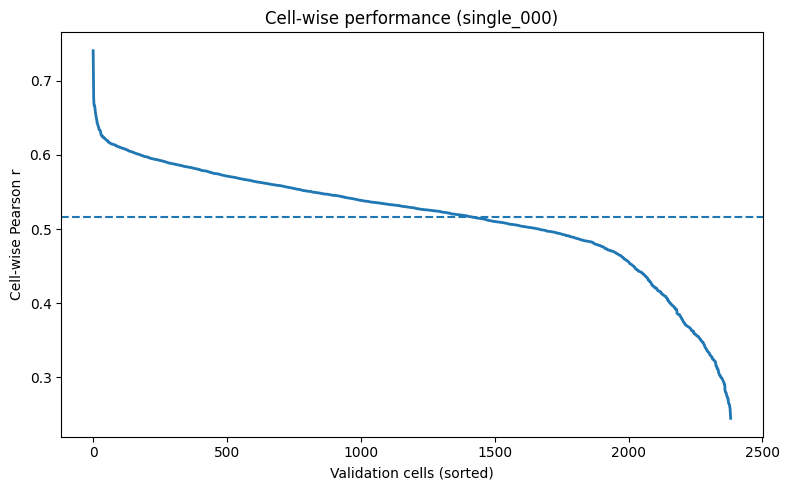

In [12]:
cell_cor_sorted = np.sort(cell_cor[~np.isnan(cell_cor)])[::-1]

plt.figure(figsize=(8, 5))
plt.plot(np.arange(len(cell_cor_sorted)), cell_cor_sorted, linewidth=2)
plt.axhline(np.nanmean(cell_cor), linestyle="--")
plt.xlabel("Validation cells (sorted)")
plt.ylabel("Cell-wise Pearson r")
plt.title(f"Cell-wise performance ({ratio_label})")
plt.tight_layout()
plt.savefig(FIGDIR / "Fig10_sorted_cellwise_correlation.png", dpi=200)
plt.show()

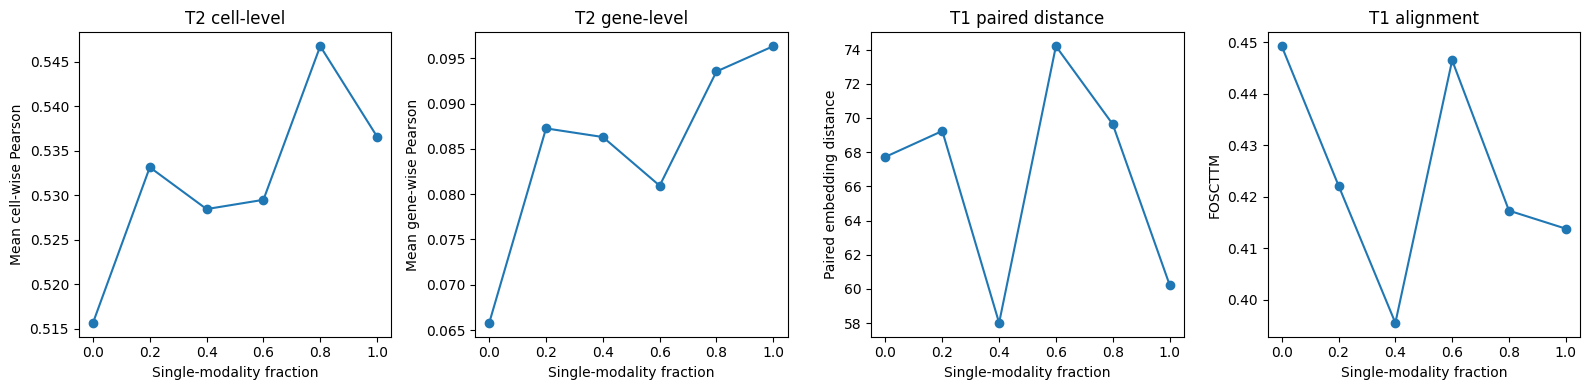

In [23]:
summary_path = BASE_DIR / "summary_all_ratios_scMRDR.csv"
summary_df = pd.read_csv(summary_path)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].plot(summary_df["single_frac"], summary_df["cellwise_pearson_mean"], marker="o")
axes[0].set_xlabel("Single-modality fraction")
axes[0].set_ylabel("Mean cell-wise Pearson")
axes[0].set_title("T2 cell-level")

axes[1].plot(summary_df["single_frac"], summary_df["genewise_pearson_mean"], marker="o")
axes[1].set_xlabel("Single-modality fraction")
axes[1].set_ylabel("Mean gene-wise Pearson")
axes[1].set_title("T2 gene-level")

axes[2].plot(summary_df["single_frac"], summary_df["paired_embedding_distance_mean"], marker="o")
axes[2].set_xlabel("Single-modality fraction")
axes[2].set_ylabel("Paired embedding distance")
axes[2].set_title("T1 paired distance")

axes[3].plot(summary_df["single_frac"], summary_df["foscttm"], marker="o")
axes[3].set_xlabel("Single-modality fraction")
axes[3].set_ylabel("FOSCTTM")
axes[3].set_title("T1 alignment")

plt.tight_layout()
plt.show()

In [14]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from scipy import sparse
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def to_dense(x):
    if sparse.issparse(x):
        return x.toarray()
    return np.asarray(x)

def get_common_names(*arrays):
    if len(arrays) == 0:
        return []
    common = set(arrays[0])
    for arr in arrays[1:]:
        common &= set(arr)
    return sorted(common)

BASE_DIR = Path("/data5/zhangye/scMRDR/scMRDR_zy/PBMC/output_pbmc_multiome/results_scMRDR_loop")
ratio_label = "single_000"
outdir = BASE_DIR / ratio_label
FIGDIR = outdir / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

pred_rna_val = sc.read_h5ad(outdir / "pred_rna_val.h5ad")
true_rna_val = sc.read_h5ad(outdir / "true_rna_val.h5ad")
t1_per_cell = pd.read_csv(outdir / "T1_per_cell_metrics.csv")
t2_cellwise = pd.read_csv(outdir / "T2_cellwise_pearson.csv")

common_cells = get_common_names(pred_rna_val.obs_names.tolist(), true_rna_val.obs_names.tolist())
common_features = get_common_names(pred_rna_val.var_names.tolist(), true_rna_val.var_names.tolist())

pred_use = pred_rna_val[common_cells, common_features].copy()
true_use = true_rna_val[common_cells, common_features].copy()

print(pred_use.shape, true_use.shape)

(2382, 19115) (2382, 19115)


In [15]:
true_mat = to_dense(true_use.X)
pred_mat = to_dense(pred_use.X)

mix = np.vstack([true_mat, pred_mat])   # cells x features
nq = true_mat.shape[0]

mix_adata = ad.AnnData(
    X=mix,
    obs=pd.DataFrame(
        {
            "group": ["True_RNA"] * nq + ["Pred_from_ATAC"] * nq,
            "cell": list(common_cells) + list(common_cells),
            "cell_id_plot": [f"true_{c}" for c in common_cells] + [f"pred_{c}" for c in common_cells],
        },
        index=[f"true_{c}" for c in common_cells] + [f"pred_{c}" for c in common_cells],
    ),
    var=pd.DataFrame(index=common_features),
)

sc.pp.normalize_total(mix_adata, target_sum=1e4)
sc.pp.log1p(mix_adata)
sc.pp.scale(mix_adata)
sc.tl.pca(mix_adata, n_comps=min(30, mix_adata.n_obs - 1, mix_adata.n_vars))
sc.pp.neighbors(mix_adata, n_pcs=min(30, mix_adata.obsm["X_pca"].shape[1]))
sc.tl.umap(mix_adata)

umap_df = pd.DataFrame(
    {
        "UMAP1": mix_adata.obsm["X_umap"][:, 0],
        "UMAP2": mix_adata.obsm["X_umap"][:, 1],
        "type": mix_adata.obs["group"].values,
        "cell": mix_adata.obs["cell"].values,
        "cell_id_plot": mix_adata.obs["cell_id_plot"].values,
    },
    index=mix_adata.obs_names,
)

umap_true = umap_df.loc[[f"true_{c}" for c in common_cells]].copy()
umap_pred = umap_df.loc[[f"pred_{c}" for c in common_cells]].copy()

print(umap_df.head())

/home/zhangye/anaconda3/envs/scmrdr/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


                             UMAP1     UMAP2      type                cell  \
true_AAACAGCCAATCCCTT-1  18.271454  6.475479  True_RNA  AAACAGCCAATCCCTT-1   
true_AAACAGCCAATGCGCT-1  15.397379  8.085657  True_RNA  AAACAGCCAATGCGCT-1   
true_AAACAGCCAGGATAAC-1  19.474857  9.523093  True_RNA  AAACAGCCAGGATAAC-1   
true_AAACAGCCAGTAGGTG-1  15.621638  8.260735  True_RNA  AAACAGCCAGTAGGTG-1   
true_AAACAGCCATCCAGGT-1   8.883237  5.885251  True_RNA  AAACAGCCATCCAGGT-1   

                                    cell_id_plot  
true_AAACAGCCAATCCCTT-1  true_AAACAGCCAATCCCTT-1  
true_AAACAGCCAATGCGCT-1  true_AAACAGCCAATGCGCT-1  
true_AAACAGCCAGGATAAC-1  true_AAACAGCCAGGATAAC-1  
true_AAACAGCCAGTAGGTG-1  true_AAACAGCCAGTAGGTG-1  
true_AAACAGCCATCCAGGT-1  true_AAACAGCCATCCAGGT-1  


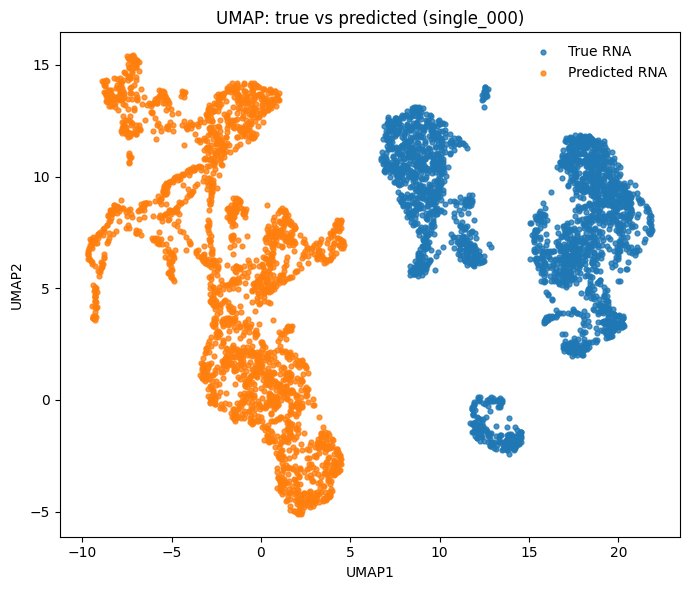

In [16]:
plt.figure(figsize=(7, 6))

mask_true = umap_df["type"] == "True_RNA"
mask_pred = umap_df["type"] == "Pred_from_ATAC"

plt.scatter(
    umap_df.loc[mask_true, "UMAP1"],
    umap_df.loc[mask_true, "UMAP2"],
    s=12, alpha=0.8, label="True RNA"
)
plt.scatter(
    umap_df.loc[mask_pred, "UMAP1"],
    umap_df.loc[mask_pred, "UMAP2"],
    s=12, alpha=0.8, label="Predicted RNA"
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title(f"UMAP: true vs predicted ({ratio_label})")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIGDIR / "Fig11_umap_joint_true_vs_pred.png", dpi=200)
plt.show()

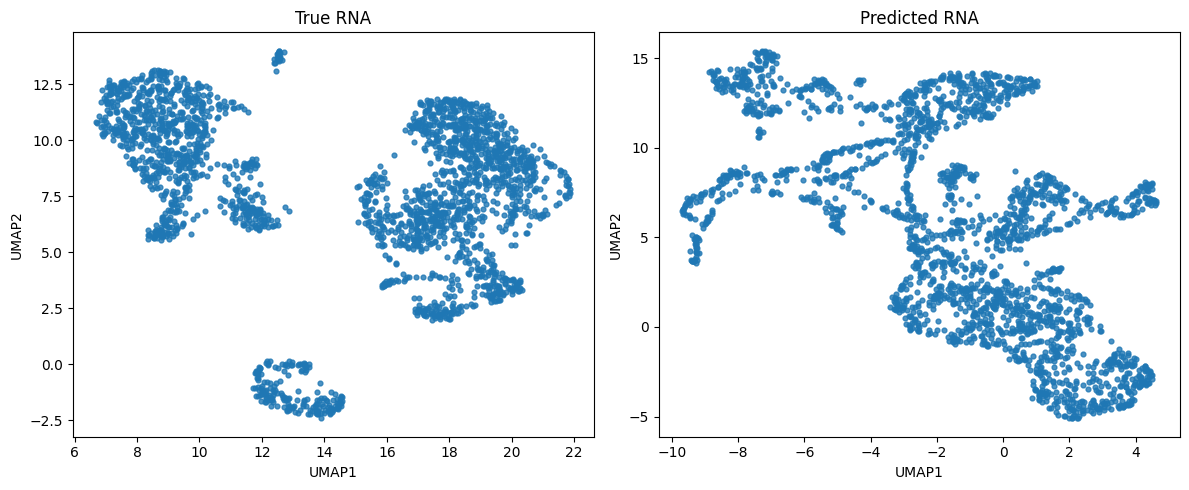

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(umap_true["UMAP1"], umap_true["UMAP2"], s=12, alpha=0.8)
axes[0].set_title("True RNA")
axes[0].set_xlabel("UMAP1")
axes[0].set_ylabel("UMAP2")

axes[1].scatter(umap_pred["UMAP1"], umap_pred["UMAP2"], s=12, alpha=0.8)
axes[1].set_title("Predicted RNA")
axes[1].set_xlabel("UMAP1")
axes[1].set_ylabel("UMAP2")

plt.tight_layout()
plt.savefig(FIGDIR / "Fig12_umap_true_pred_separate.png", dpi=200)
plt.show()

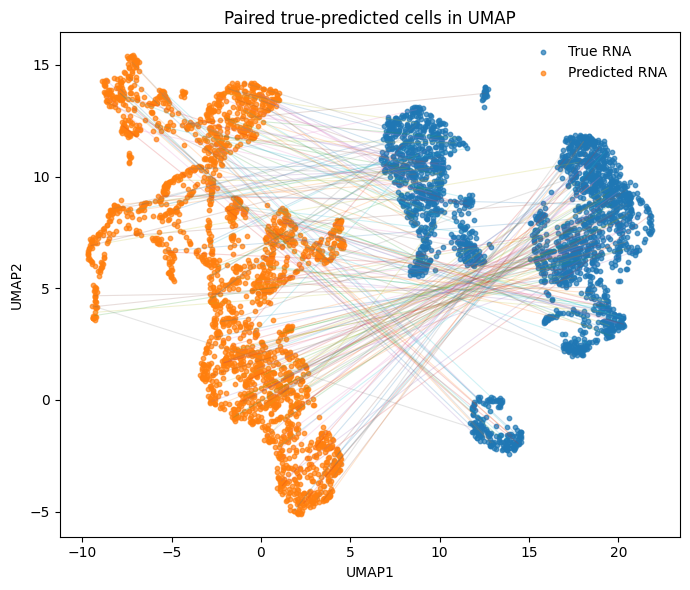

In [18]:
rng = np.random.default_rng(1234)
n_show = min(200, len(common_cells))
show_cells = rng.choice(common_cells, size=n_show, replace=False)

plt.figure(figsize=(7, 6))

plt.scatter(umap_true["UMAP1"], umap_true["UMAP2"], s=10, alpha=0.7, label="True RNA")
plt.scatter(umap_pred["UMAP1"], umap_pred["UMAP2"], s=10, alpha=0.7, label="Predicted RNA")

for cell in show_cells:
    x0 = umap_true.loc[f"true_{cell}", "UMAP1"]
    y0 = umap_true.loc[f"true_{cell}", "UMAP2"]
    x1 = umap_pred.loc[f"pred_{cell}", "UMAP1"]
    y1 = umap_pred.loc[f"pred_{cell}", "UMAP2"]
    plt.plot([x0, x1], [y0, y1], alpha=0.2, linewidth=0.8)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Paired true-predicted cells in UMAP")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIGDIR / "Fig13_umap_paired_lines.png", dpi=200)
plt.show()

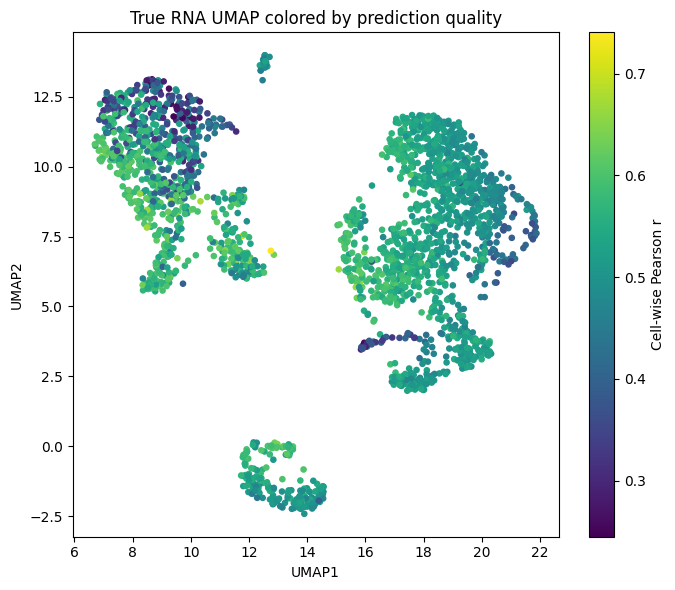

In [19]:
cell_cor_map = dict(zip(t2_cellwise["cell"], t2_cellwise["cellwise_pearson"]))
umap_true_plot = umap_true.copy()
umap_true_plot["cellwise_pearson"] = [cell_cor_map.get(c, np.nan) for c in umap_true_plot["cell"]]

plt.figure(figsize=(7, 6))
scat = plt.scatter(
    umap_true_plot["UMAP1"],
    umap_true_plot["UMAP2"],
    c=umap_true_plot["cellwise_pearson"],
    s=14
)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("True RNA UMAP colored by prediction quality")
plt.colorbar(scat, label="Cell-wise Pearson r")
plt.tight_layout()
plt.savefig(FIGDIR / "Fig14_umap_true_colored_by_cellcor.png", dpi=200)
plt.show()

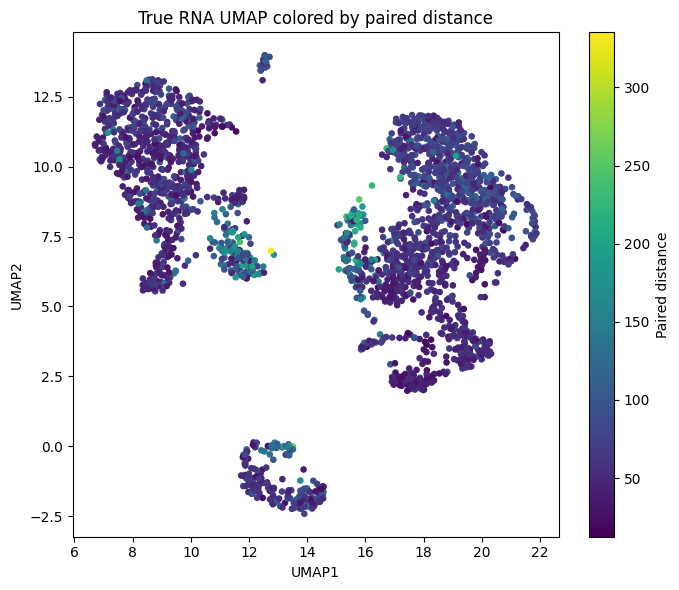

In [20]:
paired_dist_map = dict(zip(t1_per_cell["cell"], t1_per_cell["paired_dist"]))
umap_true_plot["paired_dist"] = [paired_dist_map.get(c, np.nan) for c in umap_true_plot["cell"]]

plt.figure(figsize=(7, 6))
scat = plt.scatter(
    umap_true_plot["UMAP1"],
    umap_true_plot["UMAP2"],
    c=umap_true_plot["paired_dist"],
    s=14
)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("True RNA UMAP colored by paired distance")
plt.colorbar(scat, label="Paired distance")
plt.tight_layout()
plt.savefig(FIGDIR / "Fig15_umap_true_colored_by_pairedDist.png", dpi=200)
plt.show()

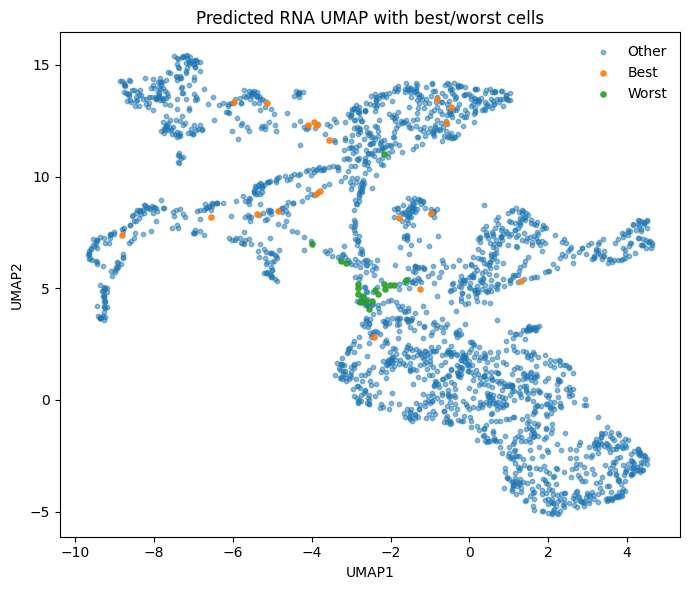

In [21]:
cell_df = t2_cellwise.dropna().sort_values("cellwise_pearson", ascending=False)
best_cells = cell_df["cell"].tolist()[:20]
worst_cells = cell_df["cell"].tolist()[-20:]

umap_pred_plot = umap_pred.copy()
group = []
for c in umap_pred_plot["cell"]:
    if c in best_cells:
        group.append("Best")
    elif c in worst_cells:
        group.append("Worst")
    else:
        group.append("Other")
umap_pred_plot["highlight_group"] = group

plt.figure(figsize=(7, 6))

for g in ["Other", "Best", "Worst"]:
    sub = umap_pred_plot[umap_pred_plot["highlight_group"] == g]
    plt.scatter(
        sub["UMAP1"], sub["UMAP2"],
        s=14 if g != "Other" else 10,
        alpha=0.9 if g != "Other" else 0.5,
        label=g
    )

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Predicted RNA UMAP with best/worst cells")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIGDIR / "Fig16_umap_pred_highlight_best_worst.png", dpi=200)
plt.show()

rna_data shape: (2382, 19115)
atac_data shape: (2382, 19115)
n common cells: 2382
n common features: 19115
coembed_mat shape: (4764, 19115)
obs shape: (4764, 2)
var shape: (19115, 0)


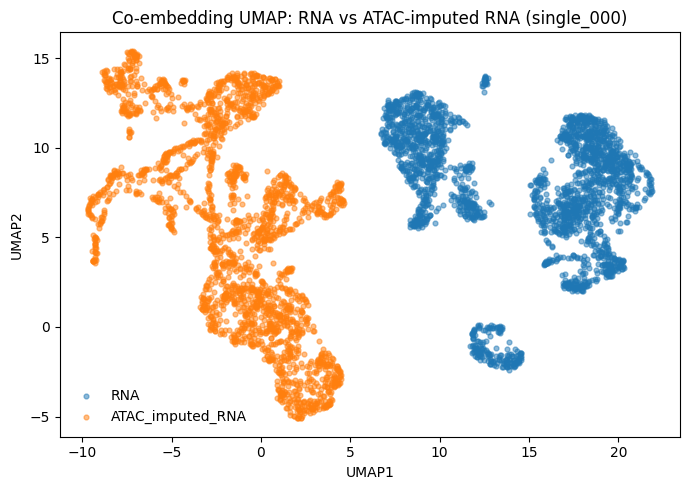

In [22]:
# -------------------------
# Fig17 / Fig18 coembed UMAP
# -------------------------

# 直接从 AnnData 重新取，避免 true_mat / pred_mat 在前面被转置过
rna_data = to_dense(true_use.X)   # cells x features
atac_data = to_dense(pred_use.X)  # cells x features

print("rna_data shape:", rna_data.shape)
print("atac_data shape:", atac_data.shape)
print("n common cells:", len(common_cells))
print("n common features:", len(common_features))

# 检查维度
assert rna_data.shape[0] == len(common_cells)
assert atac_data.shape[0] == len(common_cells)
assert rna_data.shape[1] == len(common_features)
assert atac_data.shape[1] == len(common_features)

coembed_mat = np.vstack([rna_data, atac_data])  # (2*cells) x features

coembed_obs = pd.DataFrame(
    {
        "modality": ["RNA"] * len(common_cells) + ["ATAC_imputed_RNA"] * len(common_cells),
        "cell": list(common_cells) + list(common_cells),
    },
    index=[f"{c}_rna" for c in common_cells] + [f"{c}_atac" for c in common_cells],
)

coembed_var = pd.DataFrame(index=common_features)

print("coembed_mat shape:", coembed_mat.shape)
print("obs shape:", coembed_obs.shape)
print("var shape:", coembed_var.shape)

coembed_adata = ad.AnnData(
    X=coembed_mat,
    obs=coembed_obs,
    var=coembed_var,
)

sc.pp.normalize_total(coembed_adata, target_sum=1e4)
sc.pp.log1p(coembed_adata)
sc.pp.scale(coembed_adata, zero_center=True)
sc.tl.pca(coembed_adata, n_comps=min(30, coembed_adata.n_obs - 1, coembed_adata.n_vars))
sc.pp.neighbors(coembed_adata, n_pcs=min(30, coembed_adata.obsm["X_pca"].shape[1]))
sc.tl.umap(coembed_adata)

coembed_df = pd.DataFrame(
    {
        "UMAP1": coembed_adata.obsm["X_umap"][:, 0],
        "UMAP2": coembed_adata.obsm["X_umap"][:, 1],
        "modality": coembed_adata.obs["modality"].values,
        "cell": coembed_adata.obs["cell"].values,
    },
    index=coembed_adata.obs_names,
)

# Fig17
plt.figure(figsize=(7, 5))
for g in ["RNA", "ATAC_imputed_RNA"]:
    sub = coembed_df[coembed_df["modality"] == g]
    plt.scatter(sub["UMAP1"], sub["UMAP2"], s=12, alpha=0.5, label=g)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title(f"Co-embedding UMAP: RNA vs ATAC-imputed RNA ({ratio_label})")
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIGDIR / "Fig17_coembed_umap_rna_vs_atac.png", dpi=200)
plt.show()



In [ ]:
true_x = to_dense(true_use.X).ravel()
pred_x = to_dense(pred_use.X).ravel()

print("True mean:", np.mean(true_x), "Pred mean:", np.mean(pred_x))
print("True std :", np.std(true_x),  "Pred std :", np.std(pred_x))
print("True min/max:", np.min(true_x), np.max(true_x))
print("Pred min/max:", np.min(pred_x), np.max(pred_x))

True mean: 0.1451414 Pred mean: 0.19838871
True std : 0.47393617 Pred std : 0.73558575
True min/max: 0.0 7.434565
Pred min/max: 1.472241e-07 68.5891


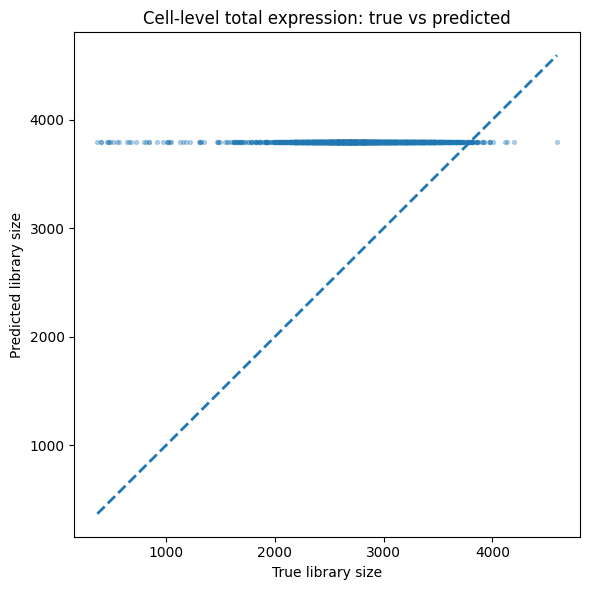

In [ ]:
true_lib = np.sum(to_dense(true_use.X), axis=1)
pred_lib = np.sum(to_dense(pred_use.X), axis=1)

plt.figure(figsize=(6, 6))
plt.scatter(true_lib, pred_lib, s=8, alpha=0.3)
mn = min(true_lib.min(), pred_lib.min())
mx = max(true_lib.max(), pred_lib.max())
plt.plot([mn, mx], [mn, mx], linestyle="--", linewidth=2)
plt.xlabel("True library size")
plt.ylabel("Predicted library size")
plt.title("Cell-level total expression: true vs predicted")
plt.tight_layout()
plt.show()

In [ ]:
rna_data = to_dense(true_use.X)   # cells x features
atac_data = to_dense(pred_use.X)  # cells x features

def zscore_by_feature(mat):
    mu = np.mean(mat, axis=0, keepdims=True)
    sd = np.std(mat, axis=0, keepdims=True)
    sd[sd == 0] = 1.0
    return (mat - mu) / sd

# 分别标准化，再拼接
rna_z = zscore_by_feature(rna_data)
atac_z = zscore_by_feature(atac_data)

coembed_mat = np.vstack([rna_z, atac_z])

coembed_adata = ad.AnnData(
    X=coembed_mat,
    obs=pd.DataFrame(
        {
            "modality": ["RNA"] * len(common_cells) + ["ATAC_imputed_RNA"] * len(common_cells),
            "cell": list(common_cells) + list(common_cells),
        },
        index=[f"{c}_rna" for c in common_cells] + [f"{c}_atac" for c in common_cells],
    ),
    var=pd.DataFrame(index=common_features),
)

sc.tl.pca(coembed_adata, n_comps=min(30, coembed_adata.n_obs - 1, coembed_adata.n_vars))
sc.pp.neighbors(coembed_adata, n_pcs=min(30, coembed_adata.obsm["X_pca"].shape[1]))
sc.tl.umap(coembed_adata)